In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_tr,X_te,y_tr,y_te = train_test_split(
    X, y_true, test_size=0.2, random_state=42)
clf = LogisticRegression().fit(X_tr, y_tr)
print(f'Supervised accuracy: {clf.score(X_te,y_te):.2%}')

Supervised accuracy: 100.00%


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
print('Cluster assignments (first 10):', cluster_labels[:10])


Cluster assignments (first 10): [1 1 0 2 1 2 0 2 0 0]


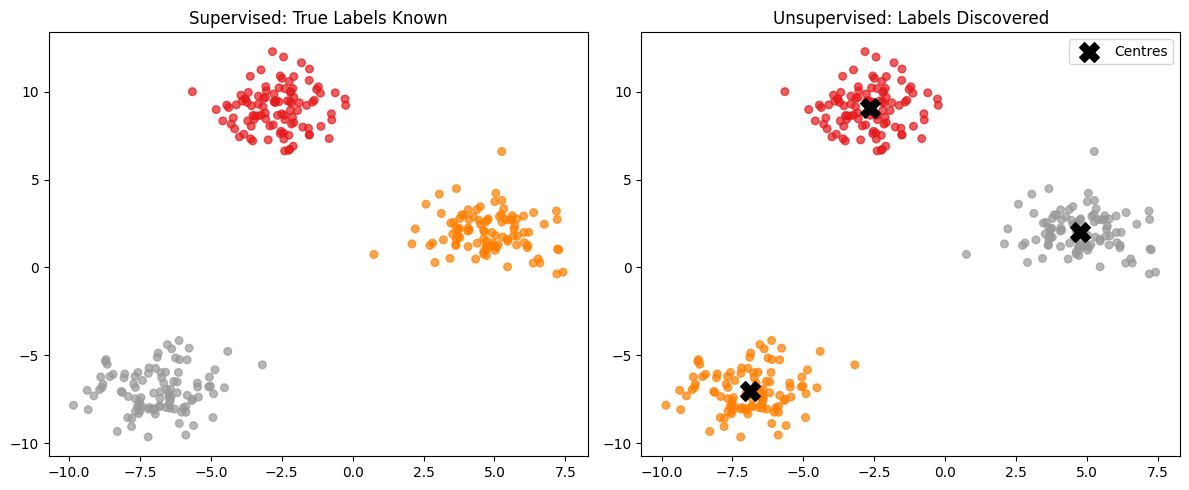

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X[:,0], X[:,1], c=y_true, cmap='Set1', s=30, alpha=0.7)
ax1.set_title('Supervised: True Labels Known', fontsize=12)
ax2.scatter(X[:,0], X[:,1], c=cluster_labels, cmap='Set1', s=30, alpha=0.7)
ax2.scatter(*kmeans.cluster_centers_.T, c='black', s=200, marker='X', label='Centres')
ax2.set_title('Unsupervised: Labels Discovered', fontsize=12)
ax2.legend(); plt.tight_layout(); plt.show()

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
def manual_kmeans(X, k=3, max_iter=10, seed=42):
  rng = np.random.default_rng(seed)
  centres = X[rng.choice(len(X), k, replace=False)]
  print(centres)
  for iteration in range(max_iter):
    dists = np.linalg.norm(X[:, np.newaxis] - centres, axis=2) # (n, k)
    labels = np.argmin(dists, axis=1) # (n,)
    new_centres = np.array([X[labels == k_].mean(axis=0) for k_ in range(k)])
    print(f'Iter {iteration+1}: centre moved by {np.linalg.norm(new_centres-centres):.4f}')
    if np.allclose(centres, new_centres): print(' → Converged!'); break
    centres = new_centres
  return labels, centres
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)
labels, centres = manual_kmeans(X, k=3)

[[ 5.5938806   2.62456094]
 [-7.70184759 -6.63642238]
 [ 3.86705362  1.73635108]]
Iter 1: centre moved by 6.2785
Iter 2: centre moved by 3.6678
Iter 3: centre moved by 0.0000
 → Converged!


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
km = KMeans(
n_clusters=3,
init='k-means++',
n_init=10,
max_iter=300,
random_state=42
)
km.fit(X_scaled)
print(f'Inertia : {km.inertia_:.2f}')
print(f'Iterations : {km.n_iter_}')
print(f'Cluster sizes: {np.bincount(km.labels_)}')

Inertia : 12.18
Iterations : 2
Cluster sizes: [67 66 67]


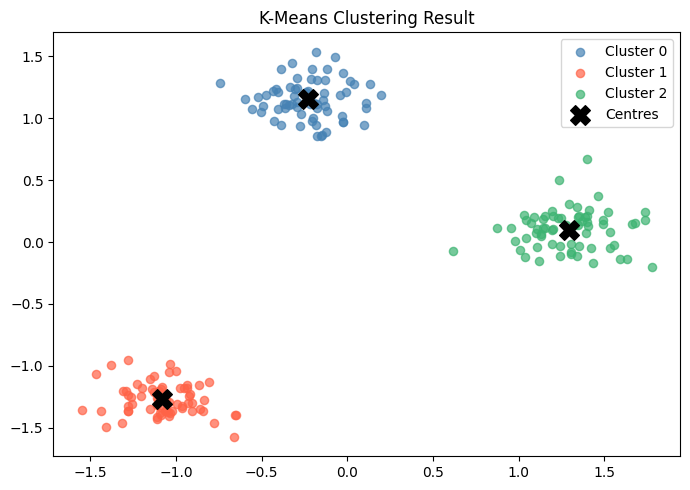

In [ ]:
plt.figure(figsize=(7,5))
colours = ['steelblue','tomato','mediumseagreen']
for k in range(3):
  mask = km.labels_ == k
  plt.scatter(X_scaled[mask,0], X_scaled[mask,1],
    c=colours[k], s=35, alpha=0.7, label=f'Cluster {k}')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
    c='black', s=200, marker='X', zorder=5, label='Centres')
plt.title('K-Means Clustering Result'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt, numpy as np
X,_= make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.5,
    random_state=42)

X = StandardScaler().fit_transform(X)

inertias, silhouettes, k_range = [], [], range(2, 11)
for k in k_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  print(k)
  km.fit(X)
  inertias.append(km.inertia_)
  sil = silhouette_score(X, km.labels_)
silhouettes.append(sil)
print(f'K={k:2d} Inertia={km.inertia_:8.2f} Silhouette={sil:.4f}')

2
3
4
5
6
7
8
9
10
K=10 Inertia=   24.51 Silhouette=0.3534


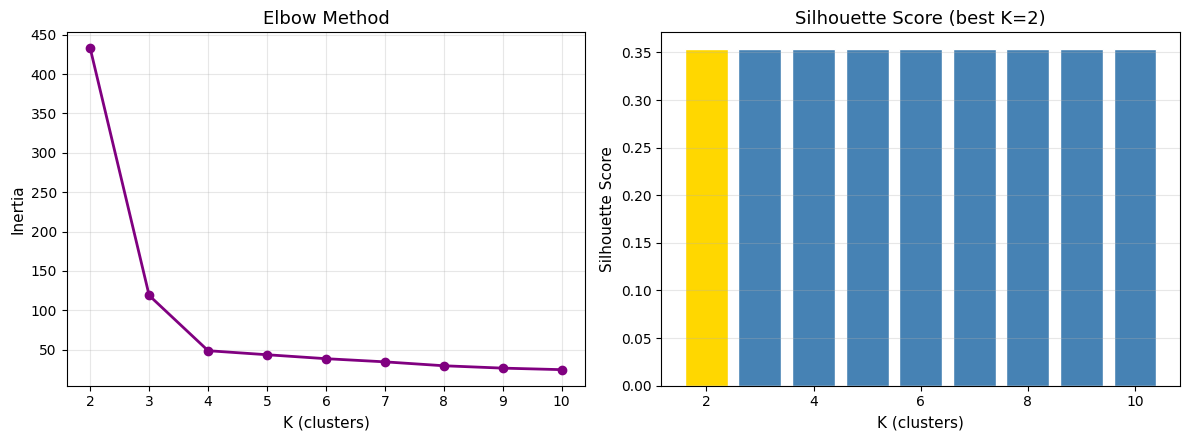


Elbow suggests: look around K=3-5
Silhouette says: best K = 2 (score=0.3534)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(k_range, inertias, 'o-', color='purple', lw=2)
ax1.set_xlabel('K (clusters)', fontsize=11); ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13); ax1.grid(alpha=0.3)
best_k = k_range[silhouettes.index(max(silhouettes))]
bars = ax2.bar(k_range, silhouettes, color=['gold' if k==best_k else 'steelblue'
for k in k_range], edgecolor='white')
ax2.set_xlabel('K (clusters)', fontsize=11); ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title(f'Silhouette Score (best K={best_k})', fontsize=13); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print(f'\nElbow suggests: look around K=3-5')
print(f'Silhouette says: best K = {best_k} (score={max(silhouettes):.4f})')

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
np.random.seed(42)
n=200
age = np.concatenate([np.random.normal(25,5,60), np.random.normal(45,8,80), np.random.normal(60,6,60)])
income = np.concatenate([np.random.normal(30,8,60), np.random.normal(60,12,80), np.random.normal(50,10,60)])
spending= np.concatenate([np.random.normal(70,10,60),np.random.normal(50,15,80), np.random.normal(30,8,60)])
df = pd.DataFrame({'Age':age,'Annual_Income':income,'Spending_Score':spending})
X = StandardScaler().fit_transform(df)
km = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = km.fit_predict(X)
colors = ['#3B82F6','#EF4444','#10B981']
cluster_names = {0:'Young Spenders', 1:'Mid-Income Balanced', 2:'Older Conservative'}

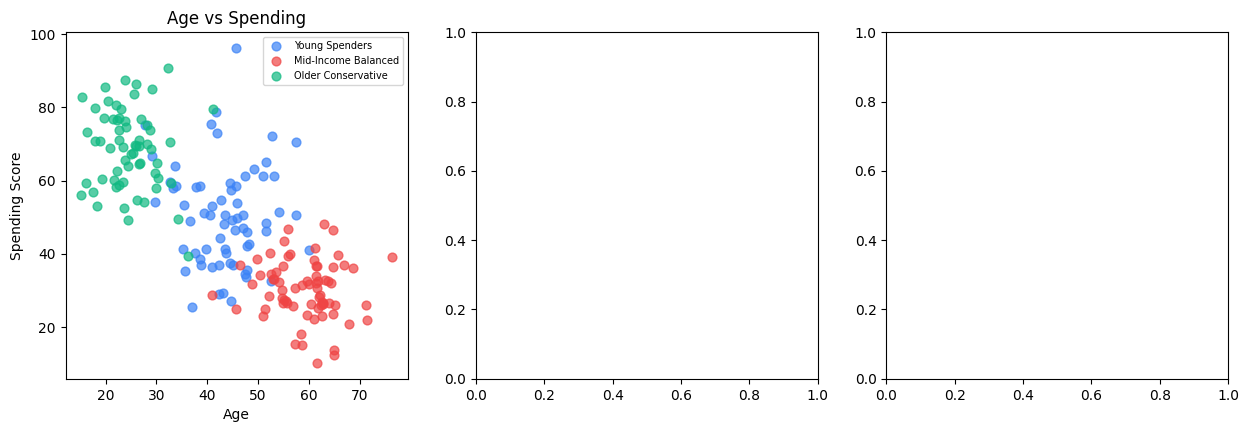

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for c in range(3):
  mask = df['Cluster'] == c
  axes[0].scatter(df[mask]['Age'], df[mask]['Spending_Score'],
    c=colors[c], s=40, alpha=0.7, label=cluster_names[c])
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Spending Score')
axes[0].set_title('Age vs Spending'); axes[0].legend(fontsize=7)

In [ ]:
for c in range(3):
  mask = df['Cluster'] == c
  axes[1].scatter(df[mask]['Annual_Income'], df[mask]['Spending_Score'],
  c=colors[c], s=40, alpha=0.7, label=cluster_names[c])
axes[1].set_xlabel('Annual Income'); axes[1].set_ylabel('Spending Score')
axes[1].set_title('Income vs Spending'); axes[1].legend(fontsize=7)

In [ ]:
profiles = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()
profiles.index = [cluster_names[i] for i in profiles.index]
profiles.T.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('Cluster Profiles (Mean Values)')
axes[2].set_xlabel('Feature'); axes[2].legend(fontsize=7)
axes[2].tick_params(axis='x', rotation=20)
plt.suptitle('Mall Customer Segments', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
print('\nCluster Summary:')
print(df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].agg(['mean','count']))


Cluster Summary:
               Age       Annual_Income       Spending_Score      
              mean count          mean count           mean count
Cluster                                                          
0        43.492533    66     62.952356    66      50.571775    66
1        59.133733    72     50.886397    72      30.288800    72
2        24.633045    62     31.265402    62      68.646316    62


In [ ]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

In [ ]:
corr_matrix = df.corr(numeric_only=True)
print('Correlation with Spending_Score:')
print(corr_matrix['Spending_Score'].sort_values(ascending=False).round(3))

Correlation with Spending_Score:
Spending_Score    1.000
Cluster           0.364
Annual_Income    -0.417
Age              -0.766
Name: Spending_Score, dtype: float64


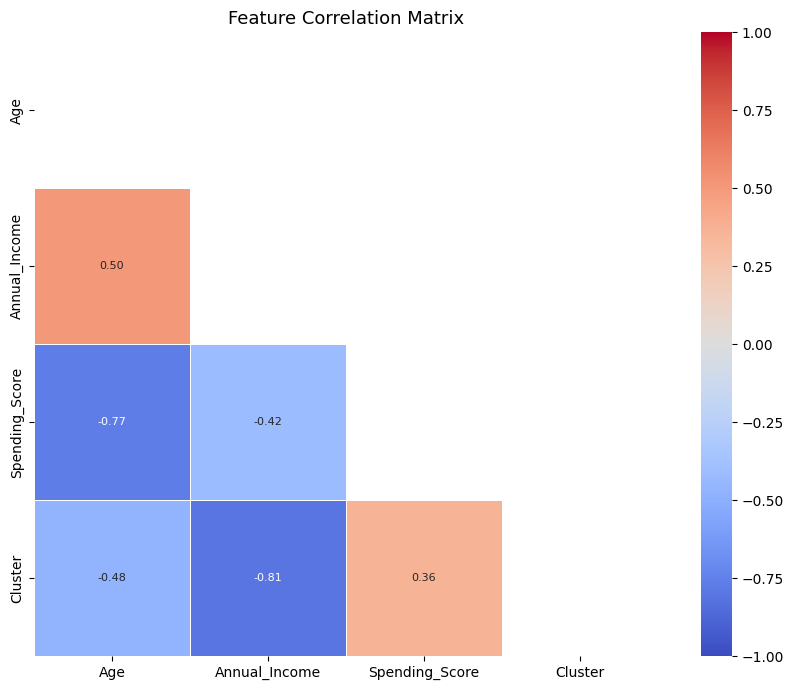

In [ ]:
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
corr_matrix,
annot=True,
fmt='.2f',
cmap='coolwarm',
mask=mask,
vmin=-1, vmax=1,
             linewidths=0.5,
square=True,
annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()